# Practica 5 - Sensado fisiológico

Primeramente ya que tenemos las mediciones separadas de las anotaciones se intenta hacer un merge entre las caracteristias que se consideraron importantes para el estudio. En este caso tomamos los tiempos de los eventos anotados, basado en esto se le asigno un timestamp a los archivos HRV

In [ ]:
import os
import pandas as pd
import numpy as np


In [ ]:
def time_to_sec(t):
    minutos, segundos = map(int, t.split(':'))
    return minutos * 60 + segundos

datos["tiempo_segundos"] = datos["time"].apply(time_to_sec)


In [ ]:

print(datos[["user", "time", "tiempo_segundos", "fear level"]].head(17))

       user  time  tiempo_segundos  fear level
0   ignacio  0:00                0           0
1   ignacio  0:56               56           0
2   ignacio  1:46              106           0
3   ignacio  2:03              123           0
4   ignacio  2:31              151           3
5   ignacio  3:24              204           3
6   ignacio  3:25              205           0
7   ignacio  4:09              249           2
8   ignacio  5:00              300           0
9   ignacio  5:27              327           0
10     juan  0:00                0           0
11     juan  1:12               72           0
12     juan  2:09              129           0
13     juan  2:26              146           0
14     juan  3:07              187           0
15     juan  3:28              208           0
16     juan  3:29              209           0


### Visualización de datos HRV

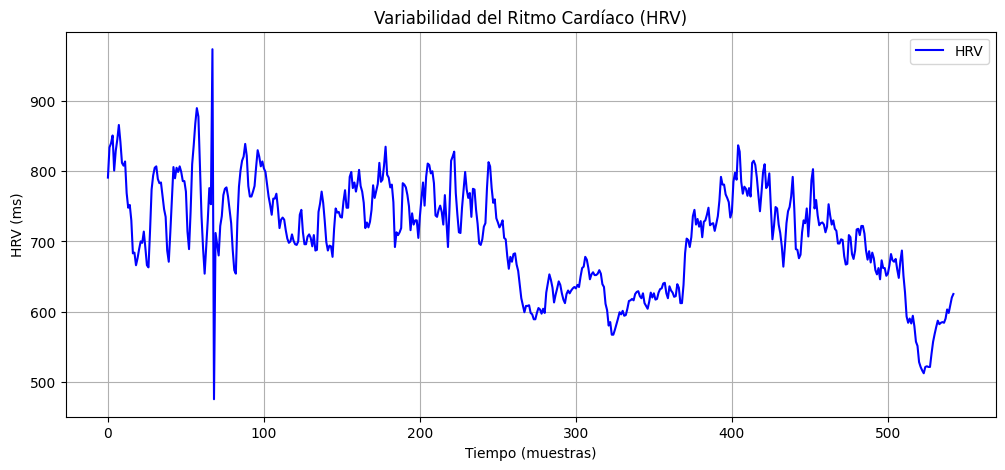

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


filename = "/content/drive/MyDrive/pract5CDSIsensadoFisio/luis.txt"  # Reemplázalo con el nombre real de tu archivo
hrv_data = np.loadtxt(filename)

# Crear la figura
plt.figure(figsize=(12, 5))
plt.plot(hrv_data, label="HRV", color='b')
plt.xlabel("Tiempo (muestras)")
plt.ylabel("HRV (ms)")
plt.title("Variabilidad del Ritmo Cardíaco (HRV)")
plt.legend()
plt.grid(True)
plt.show()


## Trasferimos la clase time a segundos para el timestamp

In [ ]:
import os
import pandas as pd
import numpy as np

df_annotations = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/fis_corregidas.csv")
df_annotations["time"] = pd.to_timedelta(df_annotations["time"])
df_annotations.head()


,user,sex,VR experience,heart/vertigo issue,time,event,fear level,hear rate file
0,ignacio,1,1,0,0 days 00:00:00,relax,0,ignacio.txt
1,ignacio,1,1,0,0 days 00:00:56,VR on,0,ignacio.txt
2,ignacio,1,1,0,0 days 00:01:46,going up in the elevator,0,ignacio.txt
3,ignacio,1,1,0,0 days 00:02:03,open elevator doors,0,ignacio.txt
4,ignacio,1,1,0,0 days 00:02:31,start walk,3,ignacio.txt


## Esneguida podemos observar las gráficas para evaluar los datos crudos

### En algunos casos es notorio un error en la toma de datos pues se llegan a presentar valores fisiológicamente erroneos con tomas arrima de 2000 y por debajo de 200, para este estudio se eliminarán dichos datos de las mediciones

<ipython-input-10-a2f95400adf9>:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 6)


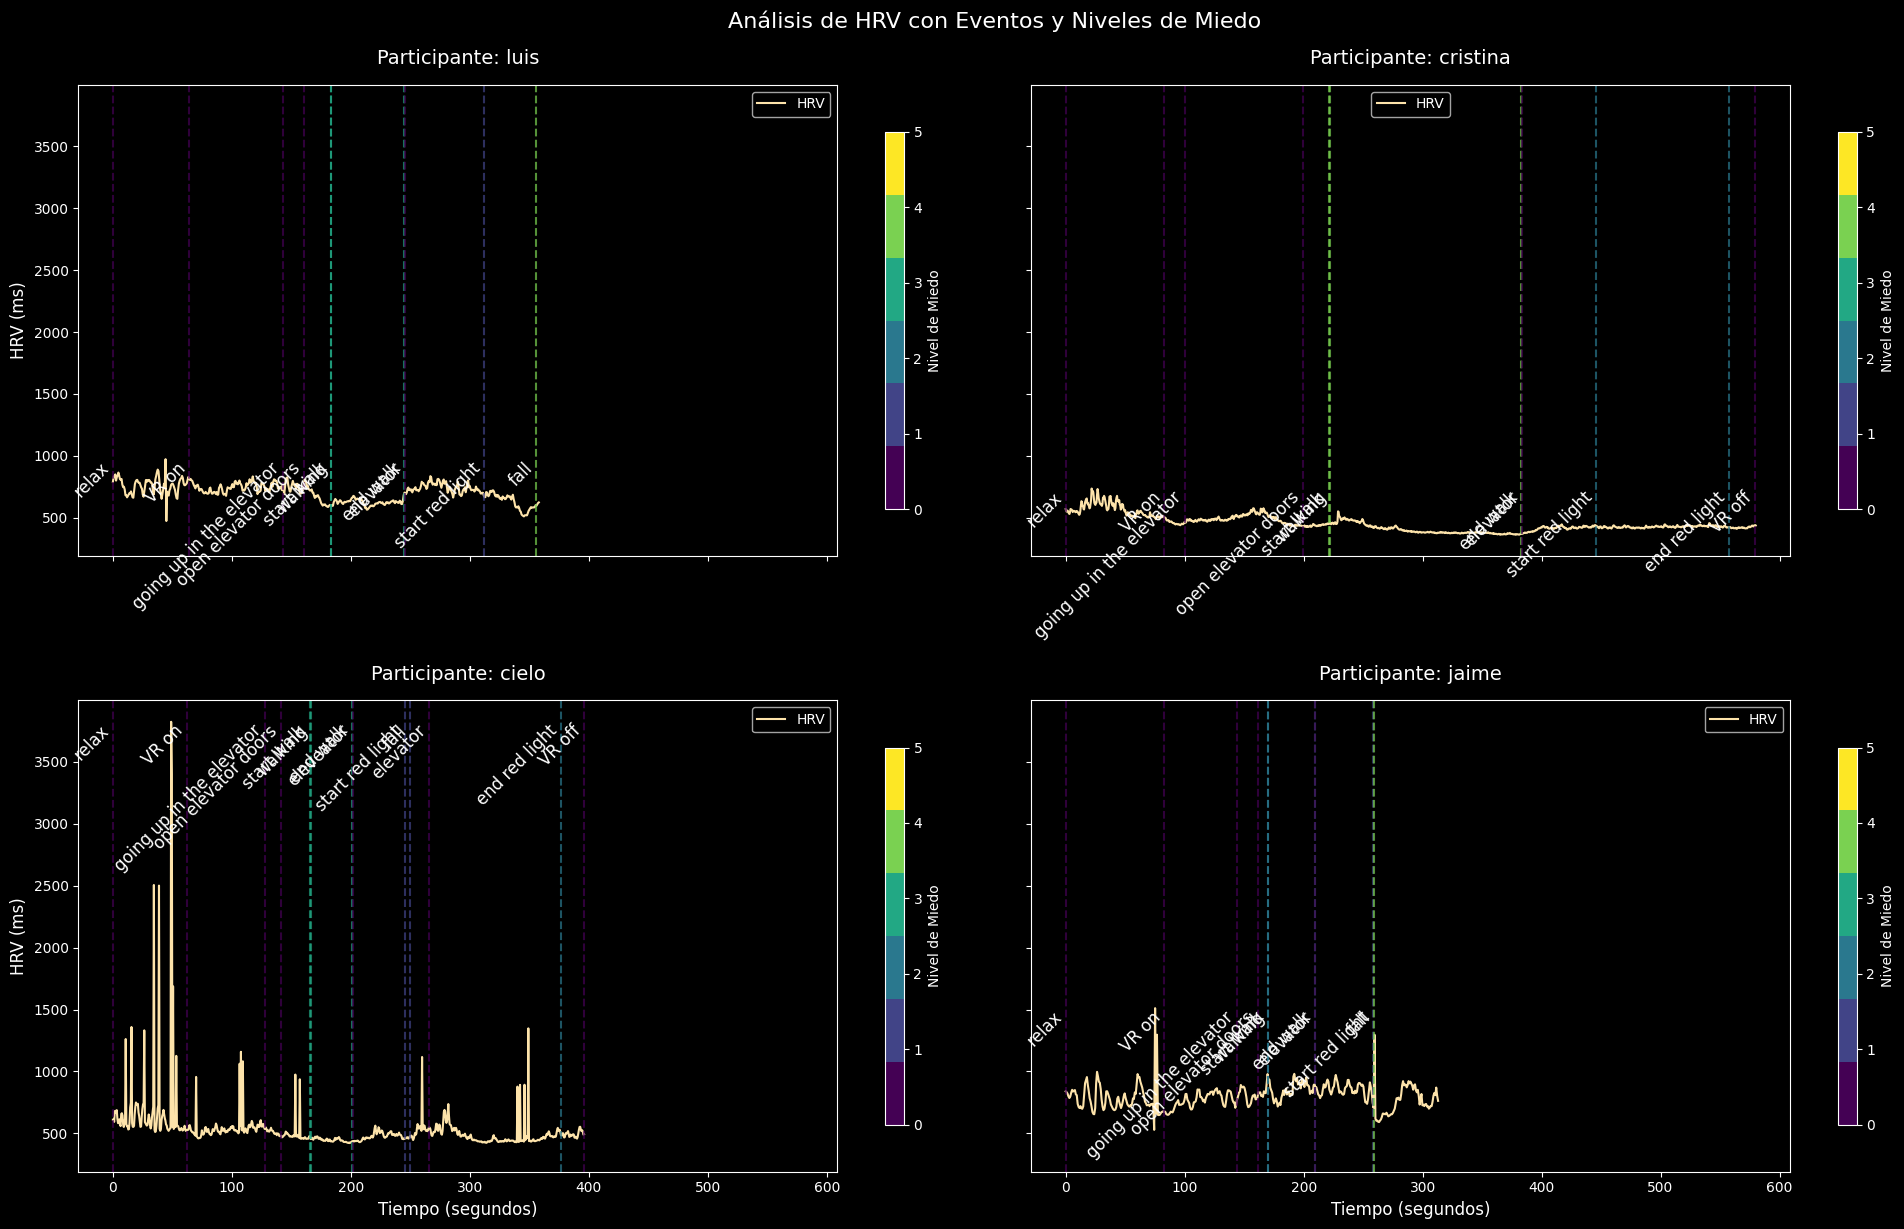

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
plt.style.use('dark_background')
sns.set_palette("husl")


df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_eventos_combinados.csv")


usuarios_unicos = df['user'].unique()
usuarios_seleccionados = np.random.choice(usuarios_unicos, size=4, replace=False)


df_filtrado = df[df['user'].isin(usuarios_seleccionados)]

fig, axs = plt.subplots(2, 2, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.ravel()

cmap = plt.cm.get_cmap('viridis', 6)

for i, usuario in enumerate(usuarios_seleccionados):

    user_data = df_filtrado[df_filtrado['user'] == usuario]

    #HRV
    sns.lineplot(
        x='timestamp_sec',
        y='hrv',
        data=user_data,
        ax=axs[i],
        linewidth=1.5,
        color='#fde3aa',
        label='HRV'
    )

    # Events line
    eventos = user_data.dropna(subset=['event']).drop_duplicates('event')
    for _, evento in eventos.iterrows():
        axs[i].axvline(
            x=evento['timestamp_sec'],
            color=cmap(evento['fear level']/5),
            linestyle='--',
            alpha=0.7,
            linewidth=1.5
        )
        axs[i].text(
            evento['timestamp_sec'],
            user_data['hrv'].max(),
            evento['event'],
            rotation=45,
            ha='right',
            va='top',
            fontsize= 12
        )


    axs[i].set_title(f'Participante: {usuario}', fontsize=14, pad=15)
    axs[i].set_xlabel('Tiempo (segundos)', fontsize=12)
    axs[i].set_ylabel('HRV (ms)', fontsize=12)
    axs[i].tick_params(axis='both', which='major', labelsize=10)

    #fearlvl
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0,5))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axs[i], shrink=0.8)
    cbar.set_label('Nivel de Miedo', fontsize=10)
    cbar.set_ticks(np.arange(0, 5.1, 1))

plt.tight_layout()
plt.suptitle('Análisis de HRV con Eventos y Niveles de Miedo', y=1.02, fontsize=16)
plt.show()

### Filtramos errores de medición

In [ ]:
import pandas as pd


df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_eventos_combinados.csv")
df_clean = df[(df['hrv'] >= 300) & (df['hrv'] <= 2000)]

df_clean = df_clean.assign(
    hrv_diff=df_clean.groupby('user')['hrv'].diff().abs()
).query('hrv_diff <= 100').drop(columns='hrv_diff')


print(f"Muestras originales: {len(df)}")
print(f"Muestras limpias: {len(df_clean)}")
print(f"Muestras eliminadas: {len(df) - len(df_clean)}")

Muestras originales: 6757
Muestras limpias: 6603
Muestras eliminadas: 154


In [ ]:
df_clean.to_csv('/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_datos_limpios.csv', index=False, encoding='utf-8')



<ipython-input-20-4135abd11879>:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 6)


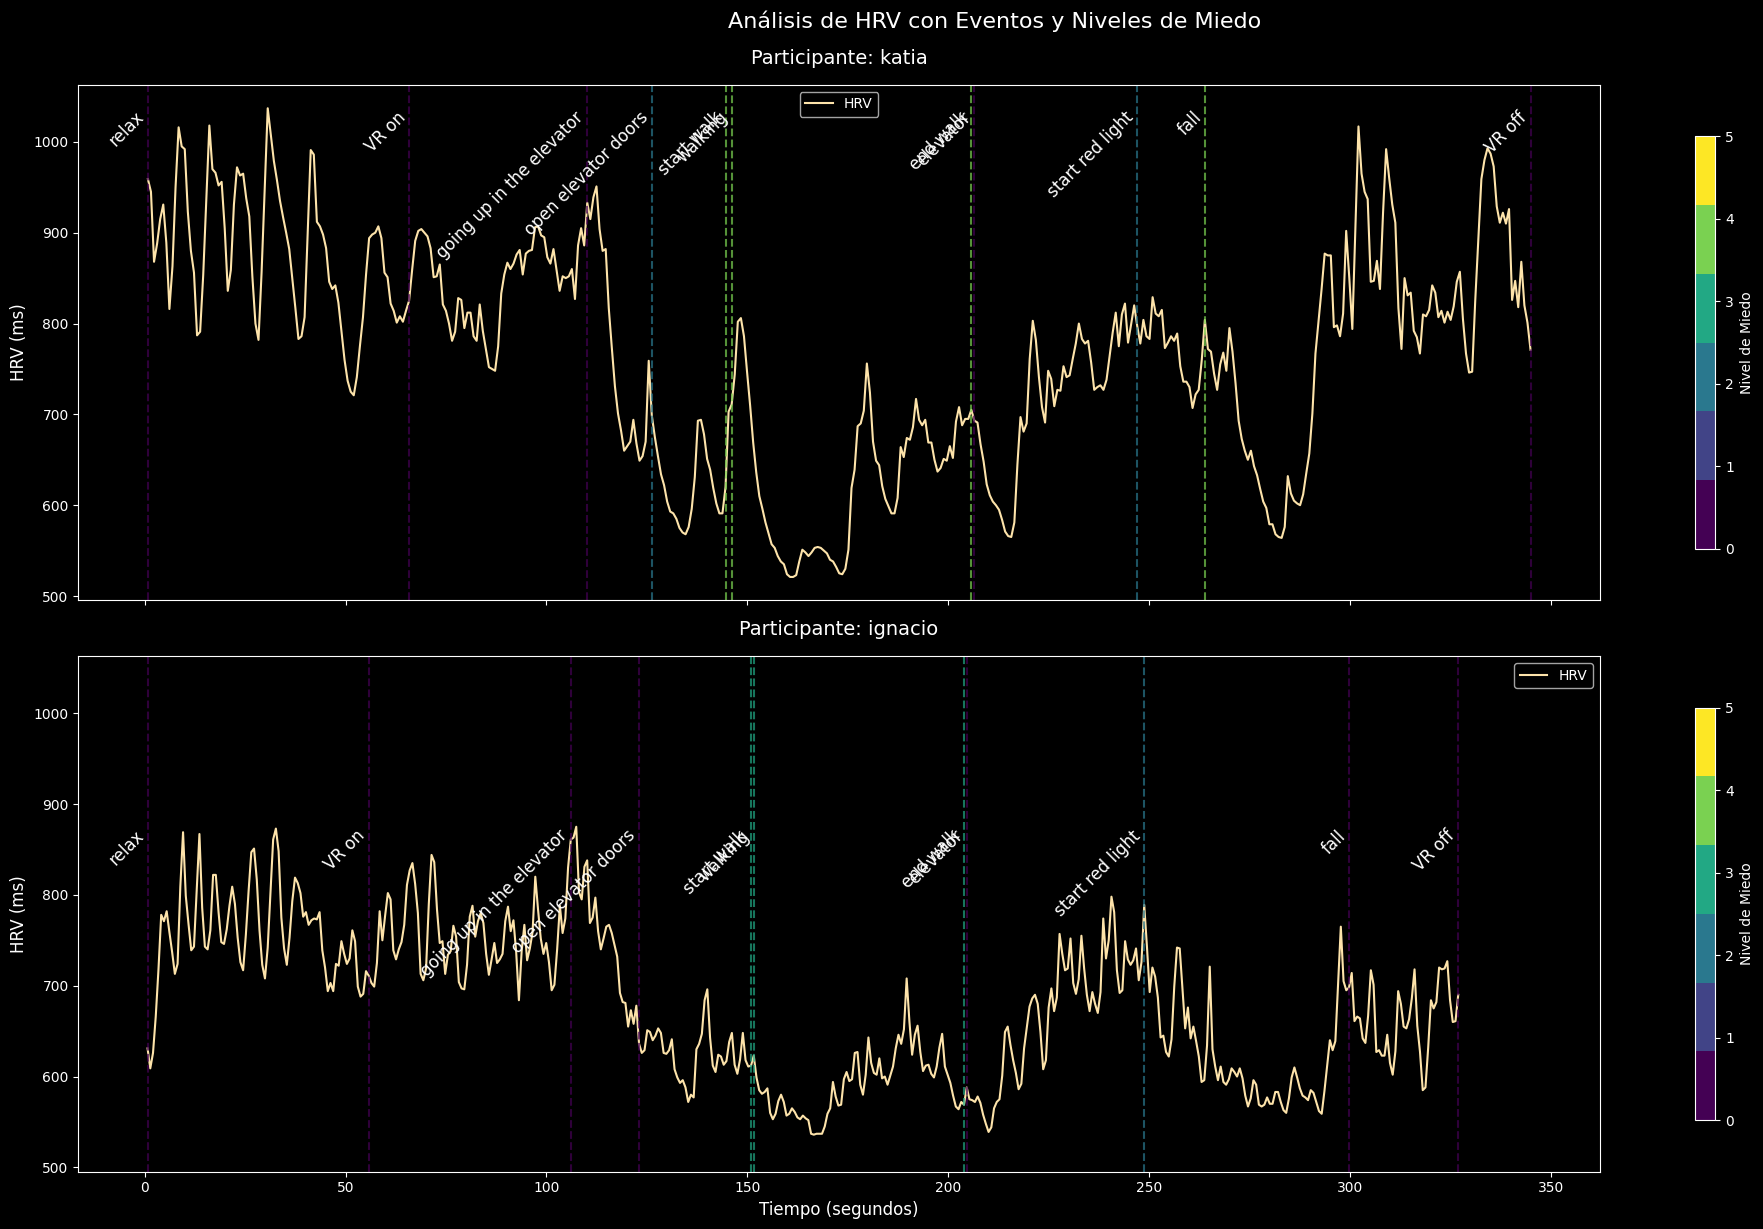

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
plt.style.use('dark_background')
sns.set_palette("husl")


df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_datos_limpios.csv")


usuarios_unicos = df['user'].unique()
usuarios_seleccionados = np.random.choice(usuarios_unicos, size=2, replace=False)


df_filtrado = df[df['user'].isin(usuarios_seleccionados)]

fig, axs = plt.subplots(2,figsize=(20, 12), sharex=True, sharey=True)
axs = axs.ravel()

cmap = plt.cm.get_cmap('viridis', 6)

for i, usuario in enumerate(usuarios_seleccionados):

    user_data = df_filtrado[df_filtrado['user'] == usuario]

    #HRV
    sns.lineplot(
        x='timestamp_sec',
        y='hrv',
        data=user_data,
        ax=axs[i],
        linewidth=1.5,
        color='#fde3aa',
        label='HRV'
    )

    # Events line
    eventos = user_data.dropna(subset=['event']).drop_duplicates('event')
    for _, evento in eventos.iterrows():
        axs[i].axvline(
            x=evento['timestamp_sec'],
            color=cmap(evento['fear level']/5),
            linestyle='--',
            alpha=0.7,
            linewidth=1.5
        )
        axs[i].text(
            evento['timestamp_sec'],
            user_data['hrv'].max(),
            evento['event'],
            rotation=45,
            ha='right',
            va='top',
            fontsize= 12
        )


    axs[i].set_title(f'Participante: {usuario}', fontsize=14, pad=15)
    axs[i].set_xlabel('Tiempo (segundos)', fontsize=12)
    axs[i].set_ylabel('HRV (ms)', fontsize=12)
    axs[i].tick_params(axis='both', which='major', labelsize=10)

    #fearlvl
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0,5))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axs[i], shrink=0.8)
    cbar.set_label('Nivel de Miedo', fontsize=10)
    cbar.set_ticks(np.arange(0, 5.1, 1))

plt.tight_layout()
plt.suptitle('Análisis de HRV con Eventos y Niveles de Miedo', y=1.02, fontsize=16)
plt.show()

## Análisis exploratorio

<ipython-input-24-5fbf26d44c71>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fear level', y='hrv', data=df, palette="coolwarm")


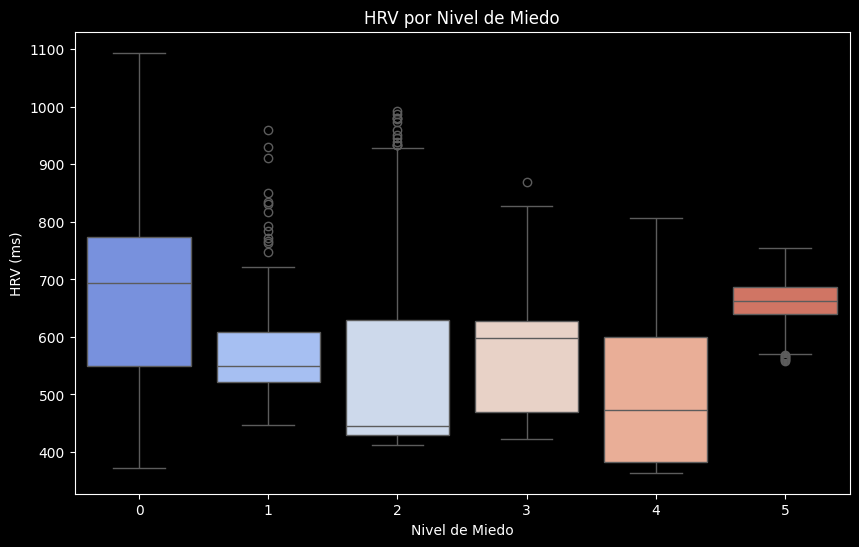

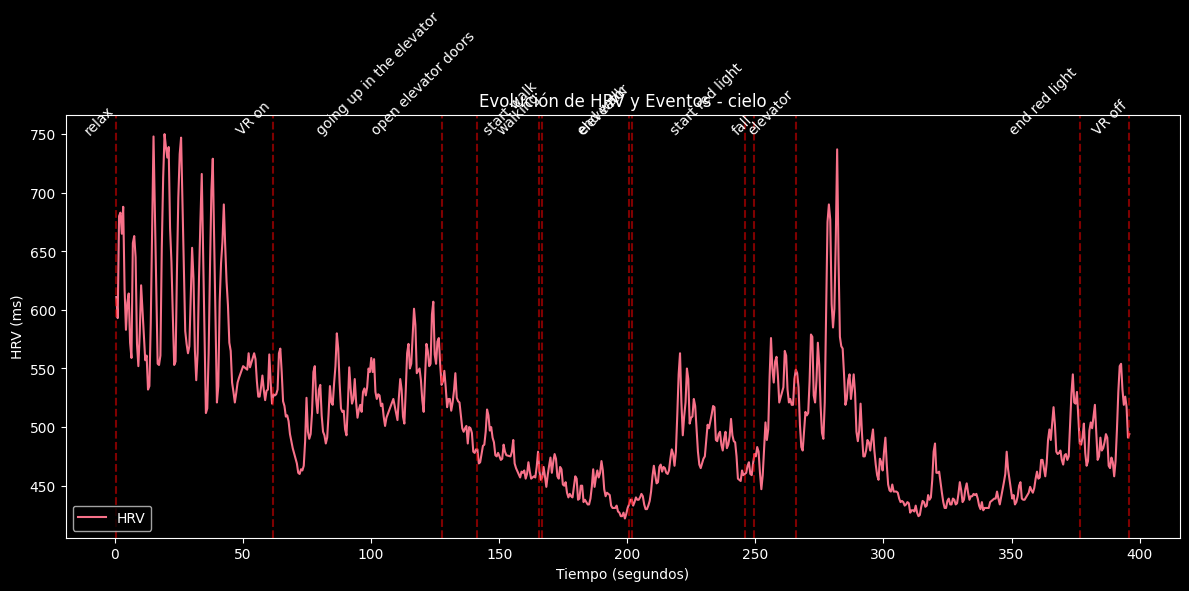

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_datos_limpios.csv")

plt.figure(figsize=(10, 6))
sns.boxplot(x='fear level', y='hrv', data=df, palette="coolwarm")
plt.title("HRV por Nivel de Miedo")
plt.xlabel("Nivel de Miedo")
plt.ylabel("HRV (ms)")


usuario_ejemplo = df['user'].iloc[2500]
df_ejemplo = df[df['user'] == usuario_ejemplo]

plt.figure(figsize=(12, 6))
sns.lineplot(x='timestamp_sec', y='hrv', data=df_ejemplo, label='HRV')
eventos = df_ejemplo.dropna(subset=['event']).drop_duplicates('event')
for _, row in eventos.iterrows():
    plt.axvline(x=row['timestamp_sec'], color='red', linestyle='--', alpha=0.5)
    plt.text(row['timestamp_sec'], df_ejemplo['hrv'].max(), row['event'], rotation=45, ha='right')
plt.title(f"Evolución de HRV y Eventos - {usuario_ejemplo}")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("HRV (ms)")
plt.tight_layout()

plt.show()

## Extracción de caracteristicas

In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_datos_limpios.csv")
def calcular_caracteristicas(grupo):
    return pd.Series({
        'hrv_mean': grupo['hrv'].mean(),
        'hrv_std': grupo['hrv'].std(),
        'hrv_rmssd': np.sqrt(np.mean(np.square(np.diff(grupo['hrv'])))),
        'hrv_change_5s': (grupo['hrv'].iloc[-1] - grupo['hrv'].iloc[0])/grupo['hrv'].iloc[0],
        'hrv_skew': grupo['hrv'].skew(),
        'hrv_kurtosis': grupo['hrv'].kurtosis()
    })


df['time_bin'] = (df['timestamp_sec'] // 30) * 30


df_features = df.groupby(['user', 'time_bin'])\
                .apply(calcular_caracteristicas)\
                .reset_index()


<ipython-input-57-33fb4386332a>:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calcular_caracteristicas)\


In [ ]:
def analisis_frecuencia(hrv_window):
    n = len(hrv_window)
    if n < 2:
        return {'lf_power': np.nan, 'hf_power': np.nan, 'lf_hf_ratio': np.nan}

    # Calcular FFT
    freqs = np.fft.fftfreq(n, d=0.5)[:n//2]
    fft_vals = np.abs(np.fft.fft(hrv_window))[:n//2]

    # (Hz)
    mask_lf = (freqs >= 0.04) & (freqs <= 0.15)
    mask_hf = (freqs > 0.15) & (freqs <= 0.4)

    lf = np.trapz(fft_vals[mask_lf]) if any(mask_lf) else 0
    hf = np.trapz(fft_vals[mask_hf]) if any(mask_hf) else 0

    return pd.Series({
        'lf_power': lf,
        'hf_power': hf,
        'lf_hf_ratio': lf / hf if hf != 0 else np.nan
    })


df['time_bin'] = (df['timestamp_sec'] // 30) * 30


df_freq_features = df.groupby(['user', 'time_bin'])['hrv']\
                     .apply(analisis_frecuencia)\
                     .reset_index()


df_final = pd.merge(
    df_features,
    df_freq_features,
    on=['user', 'time_bin'],
    how='left'
)

In [ ]:
def calcular_frecuencia(hrv_window):
    """
    Retorna un pd.Series con las métricas de frecuencia.
    """
    n = len(hrv_window)
    fs = 2.0  # (2Hz)


    lf_power = np.nan
    hf_power = np.nan
    lf_hf_ratio = np.nan

    if n >= 4:
        frecuencias = np.fft.fftfreq(n, d=1/fs)[:n//2]
        fft_valores = np.abs(np.fft.fft(hrv_window))[:n//2]

        mask_lf = (frecuencias >= 0.04) & (frecuencias <= 0.15)
        mask_hf = (frecuencias > 0.15) & (frecuencias <= 0.4)

        lf_power = np.trapz(fft_valores[mask_lf]) if mask_lf.any() else 0.0
        hf_power = np.trapz(fft_valores[mask_hf]) if mask_hf.any() else 0.0
        lf_hf_ratio = lf_power / hf_power if hf_power != 0 else np.nan


    return pd.Series({
        'LF': lf_power,
        'HF': hf_power,
        'LF_HF_ratio': lf_hf_ratio
    })


df_freq = df.groupby(['user', 'time_bin'])['hrv']\
            .apply(calcular_frecuencia)\
            .reset_index()


df_final = pd.merge(df_features, df_freq, on=['user', 'time_bin'], how='left')



In [ ]:
import pandas as pd
import numpy as np


df['time_bin'] = (df['timestamp_sec'] // 30) * 30


def calcular_caracteristicas(grupo):
    return pd.Series({
        'hrv_mean': grupo['hrv'].mean(),
        'hrv_std': grupo['hrv'].std(),
        'hrv_rmssd': np.sqrt(np.mean(np.square(np.diff(grupo['hrv']))) if len(grupo) > 1 else np.nan
        ),
        'hrv_change': (grupo['hrv'].iloc[-1] - grupo['hrv'].iloc[0])/grupo['hrv'].iloc[0] if len(grupo) > 0 else np.nan
    })


df_features = df.groupby(['user', 'time_bin']).apply(calcular_caracteristicas).reset_index()


df_final = pd.merge_asof(
    df_features.sort_values('time_bin'),
    df[['user', 'timestamp_sec', 'event', 'fear level']].drop_duplicates().sort_values('timestamp_sec'),
    left_on='time_bin',
    right_on='timestamp_sec',
    by='user',
    direction='nearest'
)


df_final[['user', 'time_bin', 'hrv_mean', 'hrv_std', 'hrv_rmssd', 'hrv_change', 'event', 'fear level']]\
       .to_csv('/content/drive/MyDrive/pract5CDSIsensadoFisio/dataset_simplificado.csv', index=False)

<ipython-input-62-daf7bc275de1>:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_features = df.groupby(['user', 'time_bin']).apply(calcular_caracteristicas).reset_index()


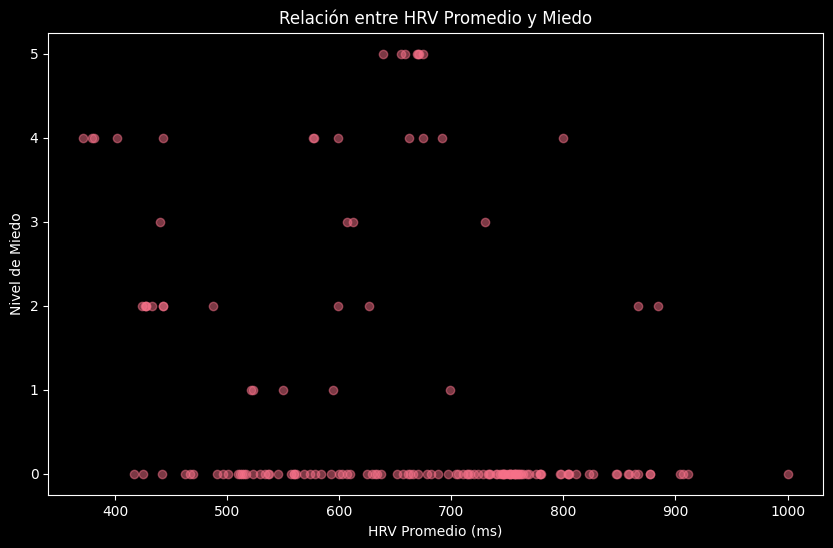

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_final['hrv_mean'], df_final['fear level'], alpha=0.5)
plt.xlabel('HRV Promedio (ms)')
plt.ylabel('Nivel de Miedo')
plt.title('Relación entre HRV Promedio y Miedo')
plt.show()

In [ ]:
display(df_final.head(15))

,user,time_bin,hrv_mean,hrv_std,hrv_rmssd,hrv_change,timestamp_sec,event,fear level
0,cielo,0.0,624.895833,66.827259,60.214510,0.000000,0.538043,relax,0
1,mario,0.0,606.764706,85.112300,51.906647,-0.001742,0.552906,relax,0
2,luis,0.0,759.955556,60.023842,26.137312,-0.041966,0.660517,relax,0
3,katia,0.0,906.918919,66.016992,53.640004,-0.107404,0.764967,relax,0
4,juan,0.0,826.275862,88.253246,83.272788,-0.028241,0.818336,relax,0
5,jorge,0.0,733.358974,81.908642,70.194842,0.048433,0.713542,relax,0
6,isabel,0.0,797.860465,67.832280,34.245264,-0.106160,0.681948,relax,0
7,ignacio,0.0,759.744186,58.372406,42.086928,0.122029,0.679834,relax,0
8,david,0.0,804.404762,43.827299,27.031147,0.010139,0.701172,relax,0
9,cristina,0.0,599.803030,54.336903,23.927133,0.102888,0.454190,relax,0


### Dataset final

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/hrv_datos_limpios.csv")


df['time_bin'] = (df['timestamp_sec'] // 30) * 30


def calcular_caracteristicas(grupo):
    hrv_data = grupo['hrv']
    diff_hrv = np.diff(hrv_data)
    return pd.Series({
        'hrv_mean': hrv_data.mean(),
        'hrv_std': hrv_data.std(),
        'hrv_rmssd': np.sqrt(np.mean(np.square(diff_hrv))) if len(diff_hrv) > 0 else np.nan,
        'hrv_change': (hrv_data.iloc[-1] - hrv_data.iloc[0])/hrv_data.iloc[0] if len(hrv_data) > 0 else np.nan
    })


def calcular_frecuencia(hrv_window):
    n = len(hrv_window)
    fs = 2.0
    lf_power = hf_power = lf_hf_ratio = np.nan

    if n >= 4:

        fft_valores = np.fft.fft(hrv_window)
        potencia = (np.abs(fft_valores) ** 2) / (fs * n)
        frecuencias = np.fft.fftfreq(n, d=1/fs)[:n//2]


        mask_lf = (frecuencias >= 0.04) & (frecuencias <= 0.15)
        mask_hf = (frecuencias > 0.15) & (frecuencias <= 0.4)

        lf_power = np.trapz(potencia[:n//2][mask_lf], frecuencias[mask_lf]) if mask_lf.any() else 0.0
        hf_power = np.trapz(potencia[:n//2][mask_hf], frecuencias[mask_hf]) if mask_hf.any() else 0.0
        lf_hf_ratio = lf_power / hf_power if hf_power != 0 else np.nan

    return pd.DataFrame({
        'LF': [lf_power],
        'HF': [hf_power],
        'LF_HF_ratio': [lf_hf_ratio]
    })


df_features = df.groupby(['user', 'time_bin']).apply(calcular_caracteristicas).reset_index()

df_freq = df.groupby(['user', 'time_bin'])['hrv']\
            .apply(calcular_frecuencia)\
            .reset_index()\
            .drop(columns=['level_2'])

df_merged = pd.merge(
    df_features,
    df_freq,
    on=['user', 'time_bin'],
    how='left'
)


df_final = pd.merge_asof(
    df_merged.sort_values('time_bin'),
    df[['user', 'timestamp_sec', 'event', 'fear level']].drop_duplicates().sort_values('timestamp_sec'),
    left_on='time_bin',
    right_on='timestamp_sec',
    by='user',
    direction='nearest'
)
df_final = df_final[(df_final['LF_HF_ratio'] >= 0.3) & (df_final['LF_HF_ratio'] <= 5)]

df_final['LF_HF_ratio'] = df_final['LF_HF_ratio'].clip(lower=0.3, upper=3)


df_final.to_csv('/content/drive/MyDrive/pract5CDSIsensadoFisio/dataset_finalcorr.csv', index=False)
print("Dataset guardado exitosamente!")

✅ Dataset guardado exitosamente!


<ipython-input-78-a2b92ffdd023>:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_features = df.groupby(['user', 'time_bin']).apply(calcular_caracteristicas).reset_index()


In [ ]:
display(df_final.head(15))

,user,time_bin,hrv_mean,hrv_std,hrv_rmssd,hrv_change,LF,HF,LF_HF_ratio,timestamp_sec,event,fear level
0,cielo,0.0,624.895833,66.827259,60.214510,0.000000,451.359724,1026.684347,0.439629,0.538043,relax,0
4,juan,0.0,826.275862,88.253246,83.272788,-0.028241,749.761766,1311.175562,0.571824,0.818336,relax,0
6,isabel,0.0,797.860465,67.832280,34.245264,-0.106160,814.650763,406.500776,2.004057,0.681948,relax,0
7,ignacio,0.0,759.744186,58.372406,42.086928,0.122029,473.458631,631.475363,0.749766,0.679834,relax,0
11,david,30.0,754.279070,37.483536,19.364917,-0.002614,208.804135,216.034981,0.966529,30.150391,relax,0
12,cielo,30.0,578.673913,60.288217,52.778573,-0.185299,357.151269,791.112546,0.451454,30.130435,relax,0
13,jorge,30.0,716.571429,45.525197,27.819540,-0.166876,157.972359,493.547929,0.320075,29.968750,relax,0
14,isabel,30.0,780.022727,57.474560,28.016191,0.208084,299.908374,664.778837,0.451140,30.005731,relax,0
16,mario,30.0,559.481481,21.871616,10.707078,-0.088183,53.070229,56.043121,0.946953,29.856930,relax,0
17,ignacio,30.0,752.372093,45.840315,31.303050,0.047170,344.990077,231.568469,1.489797,29.912682,relax,0


from matplotlib import pyplot as plt
_df_0['time_bin'].plot(kind='hist', bins=20, title='time_bin')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['hrv_mean'].plot(kind='hist', bins=20, title='hrv_mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['hrv_std'].plot(kind='hist', bins=20, title='hrv_std')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['hrv_rmssd'].plot(kind='hist', bins=20, title='hrv_rmssd')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['time_bin']
  ys = series['hrv_change']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('time_bin', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('time_bin')
_ = plt.ylabel('hrv_change')

from matplotlib import pyplot as plt
_df_12['time_bin'].plot(kind='line', figsize=(8, 4), title='time_bin')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['hrv_mean'].plot(kind='line', figsize=(8, 4), title='hrv_mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['hrv_std'].plot(kind='line', figsize=(8, 4), title='hrv_std')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['hrv_rmssd'].plot(kind='line', figsize=(8, 4), title='hrv_rmssd')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/pract5CDSIsensadoFisio/dataset_final10.csv")


In [ ]:
df

,user,time_bin,hrv_mean,hrv_std,hrv_rmssd,hrv_change,LF,HF,LF_HF_ratio,timestamp_sec,event,fear level
0,cielo,0,624.895833,66.827259,60.214510,0.000000,451.359724,1026.684347,0.439629,0.538043,relax,0
1,mario,0,606.764706,85.112300,51.906647,-0.001742,123.187745,1109.586147,0.111021,0.552906,relax,0
2,luis,0,759.955556,60.023842,26.137312,-0.041966,1043.198133,174.649289,2.973103,0.660517,relax,0
3,katia,0,906.918919,66.016992,53.640004,-0.107404,121.335592,1414.780939,0.285763,0.764967,relax,0
4,juan,0,826.275862,88.253246,83.272788,-0.028241,749.761766,1311.175562,0.571824,0.818336,relax,0
...,...,...,...,...,...,...,...,...,...,...,...,...
143,cristina,480,426.878788,6.938222,4.316337,0.011848,2.997181,7.297713,0.410701,480.078308,start red light,2
144,juan,480,699.000000,31.224990,33.541020,0.090361,50.089230,6.239405,0.407014,480.363328,fall,1
145,cristina,510,432.636364,5.758302,4.208051,-0.002331,4.609727,5.564032,0.828487,510.054816,start red light,2
146,cristina,540,427.621212,9.416459,4.774935,-0.018779,4.548059,11.826889,0.384552,540.031323,start red light,2


from matplotlib import pyplot as plt
df['time_bin'].plot(kind='hist', bins=20, title='time_bin')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['hrv_mean'].plot(kind='hist', bins=20, title='hrv_mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['hrv_std'].plot(kind='hist', bins=20, title='hrv_std')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['hrv_rmssd'].plot(kind='hist', bins=20, title='hrv_rmssd')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['time_bin']
  ys = series['hrv_change']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('time_bin', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('time_bin')
_ = plt.ylabel('hrv_change')

from matplotlib import pyplot as plt
df['time_bin'].plot(kind='line', figsize=(8, 4), title='time_bin')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['hrv_mean'].plot(kind='line', figsize=(8, 4), title='hrv_mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['hrv_std'].plot(kind='line', figsize=(8, 4), title='hrv_std')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['hrv_rmssd'].plot(kind='line', figsize=(8, 4), title='hrv_rmssd')
plt.gca().spines[['top', 'right']].set_visible(False)